<a target="_blank" href="https://colab.research.google.com/github/gupaulasan/portfolio/blob/main/Oscars%20Winner%20Prediciton/oscars.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# And the Oscar goes to...

<div  style="display: flex; justify-content:center">
    <img src="https://upload.wikimedia.org/wikipedia/en/7/7f/Academy_Award_trophy.png" alt="Academy Award" height="250px">
</div>

This is a project by <a target="_blank" href="https://www.linkedin.com/in/gustavopsantos/">Gustavo Santos</a>

The objective of this project is checking if it is possible to predict the winner of the Best Picture Oscar based on the movie's features.

## Data sources

The nominees list will be scrapped from IMDb's [Best Picture Oscar Nominees by Year (Academy Awards)](https://www.imdb.com/list/ls009487211/) list

Specific information about the movies in the list will be obtained from [OMDb](https://www.omdbapi.com/)

In [2]:
import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns

In [91]:
sns.reset_defaults()
sns.set_context('notebook')

In [3]:
#Retrieve API key from config file
omdb_key = config.omdb_key

In [37]:
#Get data from IMDb
imdb_nominees = pd.read_csv("https://www.imdb.com/list/ls009487211/export?ref_=ttls_otexp")
#Check import
imdb_nominees.head()

,Position,Const,Created,Modified,Description,Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors
0,1,tt9770150,2021-07-23,2021-07-23,*** 2021 Best Picture Winner ***,Nomadland,https://www.imdb.com/title/tt9770150/,movie,7.3,107,2020,Drama,176722,2020-09-11,Chloé Zhao
1,2,tt10272386,2021-07-23,2021-07-23,NaN,The Father,https://www.imdb.com/title/tt10272386/,movie,8.2,97,2020,"Drama, Mystery",181600,2020-01-27,Florian Zeller
2,3,tt9784798,2021-07-23,2021-07-23,NaN,Judas and the Black Messiah,https://www.imdb.com/title/tt9784798/,movie,7.4,126,2021,"Biography, Drama, History",88876,2021-02-01,Shaka King
3,4,tt10618286,2021-07-23,2021-07-23,NaN,Mank,https://www.imdb.com/title/tt10618286/,movie,6.8,131,2020,"Biography, Comedy, Drama",80952,2020-11-13,David Fincher
4,5,tt10633456,2021-07-23,2021-07-23,NaN,Minari,https://www.imdb.com/title/tt10633456/,movie,7.4,115,2020,Drama,92231,2020-01-26,Lee Isaac Chung


In [38]:
try:
    imdb_df = imdb_nominees.drop(['Position',
                              'Created',
                              'Modified',
                              'Title Type',
                              'Num Votes',
                              'Release Date',
                              'URL',
                              'Directors'
                              ], axis=1)
except:
    pass


In [39]:
# Change winners description value to 1 and nominees to 0
imdb_df.Description = imdb_df.Description.notnull().astype('int')

#Show info
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Const           480 non-null    object 
 1   Description     480 non-null    int32  
 2   Title           480 non-null    object 
 3   IMDb Rating     480 non-null    float64
 4   Runtime (mins)  480 non-null    int64  
 5   Year            480 non-null    int64  
 6   Genres          480 non-null    object 
dtypes: float64(1), int32(1), int64(2), object(3)
memory usage: 24.5+ KB


In [40]:
#Changes the string in Genres to a list of genres
imdb_df['Genres'] = imdb_df['Genres'].str.split(',')

In [41]:
imdb_df.head()

,Const,Description,Title,IMDb Rating,Runtime (mins),Year,Genres
0,tt9770150,1,Nomadland,7.3,107,2020,[Drama]
1,tt10272386,0,The Father,8.2,97,2020,"[Drama, Mystery]"
2,tt9784798,0,Judas and the Black Messiah,7.4,126,2021,"[Biography, Drama, History]"
3,tt10618286,0,Mank,6.8,131,2020,"[Biography, Comedy, Drama]"
4,tt10633456,0,Minari,7.4,115,2020,[Drama]


In [11]:
#Start session to OMDb API
session = requests.Session()

#Get IMDb ID from the movies
movies = []
for id in imdb_df['Const'].to_list():
    url = f'http://www.omdbapi.com/?apikey={omdb_key}&i={id}'
    r = session.get(url)
    data = r.json()
    movies.append(data)

In [73]:
#Create df based on the data obtained
omdb_df = pd.DataFrame(movies)
omdb_df.columns

Index(['Title', 'Year', 'Rated', 'Released', 'Runtime', 'Genre', 'Director',
       'Writer', 'Actors', 'Plot', 'Language', 'Country', 'Awards', 'Poster',
       'Ratings', 'Metascore', 'imdbRating', 'imdbVotes', 'imdbID', 'Type',
       'DVD', 'BoxOffice', 'Production', 'Website', 'Response'],
      dtype='object')

In [74]:
try:
    omdb_df = omdb_df.drop(['Released',
              'Year',
              'Title',
              'Director',
              'Writer',
              'Actors',
              'Awards',
              'Poster',
              'imdbVotes',
              'Type',
              'DVD',
              'Production',
              'Website',
              'Response',
              'Ratings',
              'imdbRating',
              'Runtime',
              'Genre'              
              ], axis=1)
except:
    pass
display(omdb_df.info())
omdb_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rated      480 non-null    object
 1   Plot       480 non-null    object
 2   Language   480 non-null    object
 3   Country    480 non-null    object
 4   Metascore  480 non-null    object
 5   imdbID     480 non-null    object
 6   BoxOffice  480 non-null    object
dtypes: object(7)
memory usage: 26.4+ KB


None

,Rated,Plot,Language,Country,Metascore,imdbID,BoxOffice
0,R,"A woman in her sixties, after losing everythin...",English,United States,91,tt9770150,"$3,700,000"
1,PG-13,A man refuses all assistance from his daughter...,English,"United Kingdom, France, United States",88,tt10272386,"$2,122,771"
2,R,"Offered a plea deal by the FBI, William O'Neal...",English,United States,85,tt9784798,"$5,478,009"
3,R,1930s Hollywood is re-evaluated through the ey...,"English, German, Latin",United States,79,tt10618286,N/A
4,PG-13,A Korean American family moves to an Arkansas ...,"Korean, English",United States,89,tt10633456,"$3,110,580"


In [75]:
omdb_df = omdb_df.replace({'N/A':np.nan})
omdb_df['BoxOffice'] = omdb_df['BoxOffice'].str.replace('$', '')
omdb_df['BoxOffice'] = omdb_df['BoxOffice'].str.replace(',', '')
omdb_df['Language'] = omdb_df['Language'].str.split(',')

In [76]:
imdb_df = imdb_df.rename({'Const':'imdbID', 'Description':'awardWinner'}, axis=1)
nominees = imdb_df.merge(omdb_df, on='imdbID', suffixes=('_imdb','_omdb'))
display(nominees.head(5))
nominees.info()

,imdbID,awardWinner,Title,IMDb Rating,Runtime (mins),Year,Genres,Rated,Plot,Language,Country,Metascore,BoxOffice
0,tt9770150,1,Nomadland,7.3,107,2020,[Drama],R,"A woman in her sixties, after losing everythin...",[English],United States,91,3700000
1,tt10272386,0,The Father,8.2,97,2020,"[Drama, Mystery]",PG-13,A man refuses all assistance from his daughter...,[English],"United Kingdom, France, United States",88,2122771
2,tt9784798,0,Judas and the Black Messiah,7.4,126,2021,"[Biography, Drama, History]",R,"Offered a plea deal by the FBI, William O'Neal...",[English],United States,85,5478009
3,tt10618286,0,Mank,6.8,131,2020,"[Biography, Comedy, Drama]",R,1930s Hollywood is re-evaluated through the ey...,"[English, German, Latin]",United States,79,NaN
4,tt10633456,0,Minari,7.4,115,2020,[Drama],PG-13,A Korean American family moves to an Arkansas ...,"[Korean, English]",United States,89,3110580


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   imdbID          480 non-null    object 
 1   awardWinner     480 non-null    int32  
 2   Title           480 non-null    object 
 3   IMDb Rating     480 non-null    float64
 4   Runtime (mins)  480 non-null    int64  
 5   Year            480 non-null    int64  
 6   Genres          480 non-null    object 
 7   Rated           479 non-null    object 
 8   Plot            480 non-null    object 
 9   Language        480 non-null    object 
 10  Country         480 non-null    object 
 11  Metascore       404 non-null    object 
 12  BoxOffice       347 non-null    object 
dtypes: float64(1), int32(1), int64(2), object(9)
memory usage: 47.0+ KB


In [79]:
mapper = {'Rated':'category', 'Metascore':'float', 'BoxOffice':'float'}
nominees = nominees.astype(mapper)
nominees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   imdbID          480 non-null    object  
 1   awardWinner     480 non-null    int32   
 2   Title           480 non-null    object  
 3   IMDb Rating     480 non-null    float64 
 4   Runtime (mins)  480 non-null    int64   
 5   Year            480 non-null    int64   
 6   Genres          480 non-null    object  
 7   Rated           479 non-null    category
 8   Plot            480 non-null    object  
 9   Language        480 non-null    object  
 10  Country         480 non-null    object  
 11  Metascore       404 non-null    float64 
 12  BoxOffice       347 non-null    float64 
dtypes: category(1), float64(3), int32(1), int64(2), object(6)
memory usage: 44.1+ KB


In [80]:
nominees['IMDb Rating'] = nominees['IMDb Rating']*10

## EDA


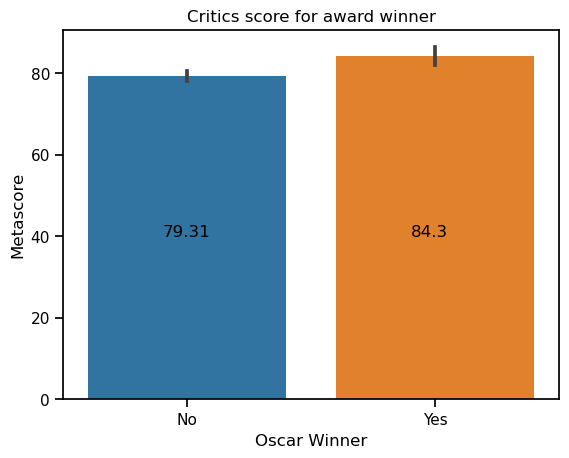

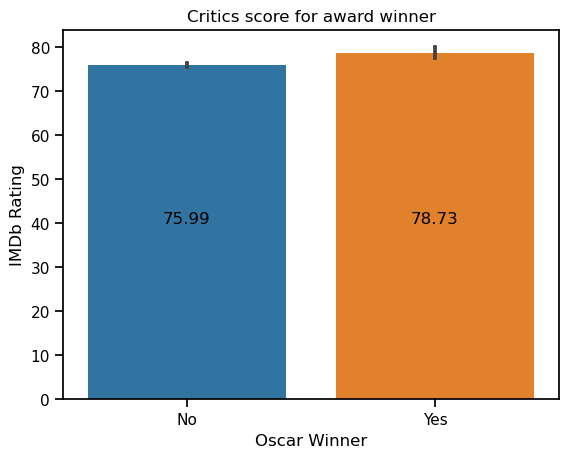

In [101]:
sns.barplot(data=nominees,
            x="awardWinner",
            y='Metascore')
plt.xticks([0,1], labels=['No', 'Yes'])
plt.xlabel('Oscar Winner')
notWinnerMean = nominees[nominees["awardWinner"]== 0]['Metascore'].mean()
plt.text(x=-0.1, y=40, s=f'{round(notWinnerMean,2)}')
winnerMean = nominees[nominees["awardWinner"]== 1]['Metascore'].mean()
plt.text(x=0.9, y=40, s=f'{round(winnerMean,2)}')
plt.title('Critics score for award winner')
plt.show()

sns.barplot(data=nominees,
            x="awardWinner",
            y='IMDb Rating')
plt.xticks([0,1], labels=['No', 'Yes'])
plt.xlabel('Oscar Winner')
notWinnerMean = nominees[nominees["awardWinner"]== 0]['IMDb Rating'].mean()
plt.text(x=-0.1, y=40, s=f'{round(notWinnerMean,2)}')
winnerMean = nominees[nominees["awardWinner"]== 1]['IMDb Rating'].mean()
plt.text(x=0.9, y=40, s=f'{round(winnerMean,2)}')
plt.title('Critics score for award winner')
plt.show()